이상 데이터 추출

In [61]:
import pandas as pd
import numpy as np

In [62]:
df_test = pd.read_csv('test_features.csv')
df_train = pd.read_csv('train_features.csv')
df_valid = pd.read_csv('valid_features.csv')

In [63]:
#3개의 df 각각 전처리

feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

# 1. inf 값을 NaN으로 바꾸기
df_test = df_test.replace([np.inf, -np.inf], np.nan)
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_valid = df_valid.replace([np.inf, -np.inf], np.nan)

# 2. feature 컬럼 기준 결측치 제거
df_test = df_test.dropna(subset=feature_cols).copy()
df_train = df_train.dropna(subset=feature_cols).copy()
df_valid = df_valid.dropna(subset=feature_cols).copy()

# 3. 너무 큰 값 잘라내기: 극단값 완화
for col in feature_cols:
    lower = df_test[col].quantile(0.01)
    upper = df_test[col].quantile(0.99)
    df_test[col] = df_test[col].clip(lower, upper)
    lower = df_train[col].quantile(0.01)
    upper = df_train[col].quantile(0.99)
    df_train[col] = df_train[col].clip(lower, upper)
    lower = df_valid[col].quantile(0.01)
    upper = df_valid[col].quantile(0.99)
    df_valid[col] = df_valid[col].clip(lower, upper)

# 4. X 생성
X_test = df_test[feature_cols].copy()
X_train = df_train[feature_cols].copy()
X_valid = df_valid[feature_cols].copy()
print("test dataset 전처리 완료 및 크기")
print(X_test.isna().sum())
print(np.isinf(X_test).sum())
print(X_test.shape)
print("train dataset 전처리 완료 및 크기")
print(X_train.isna().sum())
print(np.isinf(X_train).sum())
print(X_train.shape)
print("validation dataset 전처리 완료 및 크기")
print(X_valid.isna().sum())
print(np.isinf(X_valid).sum())
print(X_valid.shape)

test dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
(3698, 8)
train dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtyp

In [64]:
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()
df_valid_scaled = df_valid.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_train[feature_cols])
df_train_scaled[feature_cols] = scaler.transform(df_train[feature_cols])
df_test_scaled[feature_cols] = scaler.transform(df_test[feature_cols])
df_valid_scaled[feature_cols] = scaler.transform(df_valid[feature_cols])

X_test_scaled = df_test_scaled[feature_cols].copy()
X_train_scaled = df_train_scaled[feature_cols].copy()
X_valid_scaled = df_valid_scaled[feature_cols].copy()

X_train_scaled.head()

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,-0.144590,-0.655294,-0.019492,-0.882692,-0.586969,-1.240012,0.375525,0.534481
1,0.233756,-0.336517,-0.200084,-1.031000,-0.480942,-0.615611,-0.357393,0.534481
2,1.392300,1.134687,-1.198665,-0.604246,0.157921,-0.779927,0.210512,0.534481
3,-0.646832,0.108484,0.728194,-0.323677,-0.422249,-0.754366,0.502202,-0.424950
4,-1.036270,-1.181900,0.530983,-0.220504,-0.796057,-0.693661,-0.052010,-1.384381


In [66]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
iso_model.fit(X_train_scaled)

#이상치 점수
df_train_scaled["anomaly_score"] = -iso_model.decision_function(X_train_scaled)
df_test_scaled["anomaly_score"] = -iso_model.decision_function(X_test_scaled)
df_valid_scaled["anomaly_score"] = -iso_model.decision_function(X_valid_scaled)
#label명 바꾸기 (정상:1, 이상치:-1) => (정상:0, 이상치:1)
df_train_scaled["anomaly_label"] = iso_model.predict(X_train_scaled)
df_train_scaled["anomaly_label"] = df_train_scaled["anomaly_label"].map({1: 0, -1: 1})
df_test_scaled["anomaly_label"] = iso_model.predict(X_test_scaled)
df_test_scaled["anomaly_label"] = df_test_scaled["anomaly_label"].map({1: 0, -1: 1})
df_valid_scaled["anomaly_label"] = iso_model.predict(X_valid_scaled)
df_valid_scaled["anomaly_label"] = df_valid_scaled["anomaly_label"].map({1: 0, -1: 1})

#정상 데이터와 이상 데이터 개수 표시
df_test_scaled["anomaly_label"].value_counts()

anomaly_label
0    3539
1     159
Name: count, dtype: int64

In [68]:
df_test_scaled.head()

,date,adj_close,close,high,low,open,volume,ticker,group,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d,anomaly_score,anomaly_label
0,2026-03-25,16660.0,16660.0,16750.0,16600.0,16700.0,110810.0,000080.KS,Medium,-0.289572,-0.675238,-0.043488,-0.243230,-0.864405,0.216924,-0.384538,0.534481,-0.230533,0
1,2026-03-26,16540.0,16540.0,16780.0,16430.0,16780.0,118977.0,000080.KS,Medium,-0.140895,-0.613357,-0.307616,-0.423872,-0.693248,-1.240012,0.212655,0.534481,-0.214407,0
2,2026-03-27,16730.0,16730.0,16740.0,16330.0,16510.0,132871.0,000080.KS,Medium,-0.095828,-0.493258,0.440014,-0.366307,-0.992688,-1.133407,0.000128,-0.424950,-0.225221,0
3,2026-03-30,16470.0,16470.0,16700.0,16350.0,16430.0,83695.0,000080.KS,Medium,-0.605205,-0.798315,-0.641148,-0.434862,-0.621405,1.632233,-0.601699,-0.424950,-0.188726,0
4,2026-03-31,16720.0,16720.0,17090.0,16400.0,16410.0,276697.0,000080.KS,Medium,2.194555,0.537544,0.587691,-0.590948,-0.545309,1.103755,-0.124299,0.534481,-0.141720,0


In [69]:
#이상치 점수가 가장 높은 30개의 데이터 확인
top_anomaly = (
    df_train_scaled
    .sort_values("anomaly_score", ascending=False)
    .head(30)
)

top_anomaly[[
    "date",
    "ticker",
    "anomaly_score",
    "vol_chg_rate",
    "volume_ma20_ratio",
    "volatility_5d",
    "upper_shadow_ratio"
]]

,date,ticker,anomaly_score,vol_chg_rate,volume_ma20_ratio,volatility_5d,upper_shadow_ratio
18377,2024-09-25,021040.KQ,0.144130,5.026512,5.548866,4.402006,2.584445
18521,2025-04-30,021040.KQ,0.131256,6.052303,5.548866,4.402006,2.438391
34098,2025-09-12,060230.KQ,0.129489,6.052303,5.548866,3.806809,2.297793
33550,2025-03-21,058450.KQ,0.126341,6.052303,5.548866,4.402006,-1.240012
37721,2025-09-01,083660.KQ,0.126259,6.052303,5.548866,4.402006,-1.190230
33968,2025-03-06,060230.KQ,0.123465,6.052303,5.548866,4.402006,-1.087984
37715,2025-08-22,083660.KQ,0.120749,6.052303,5.548866,4.402006,-0.217857
37754,2025-10-23,083660.KQ,0.118504,6.052303,5.548866,4.033392,-0.137808
18525,2025-05-09,021040.KQ,0.118094,6.052303,5.548866,4.402006,-1.240012
33434,2024-09-25,058450.KQ,0.117759,5.516281,5.548866,4.402006,-0.163146


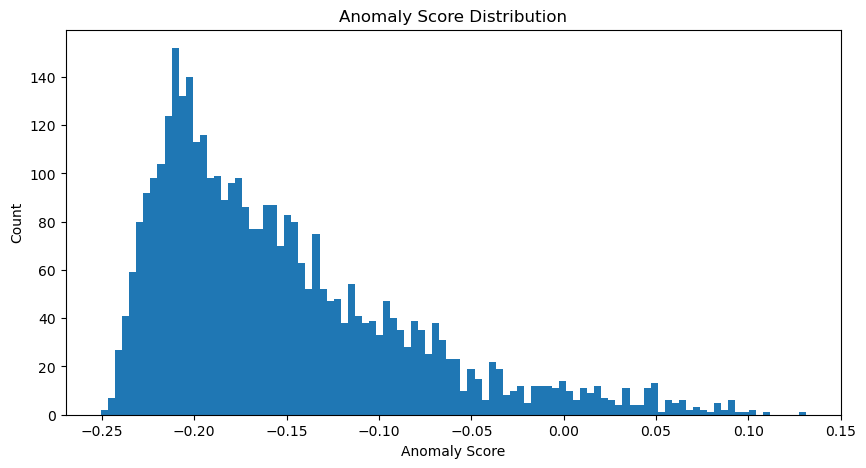

In [84]:
#이상치 점수 분포 확인
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_test_scaled["anomaly_score"], bins=100)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.savefig('Anomaly Score Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

이상 데이터 분리 후 클러스터링

In [70]:
#이상 데이터만 따로 분류
anomaly_train_df = df_train_scaled[
    df_train_scaled["anomaly_label"] == 1
].copy()

anomaly_test_df = df_test_scaled[
    df_test_scaled["anomaly_label"] == 1
].copy()

anomaly_valid_df = df_valid_scaled[
    df_valid_scaled["anomaly_label"] == 1
].copy()

In [71]:
#클러스터링에 사용할 feature들

cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_train_cluster = anomaly_train_df[cluster_feature_cols].copy()
X_test_cluster = anomaly_test_df[cluster_feature_cols].copy()
X_valid_cluster = anomaly_valid_df[cluster_feature_cols].copy()

#클러스터링 전 전처리: 무한대 값 및 결측치 포함된 행 제거
X_train_cluster = X_train_cluster.replace([np.inf, -np.inf], np.nan)
X_train_cluster = X_train_cluster.dropna()
X_test_cluster = X_test_cluster.replace([np.inf, -np.inf], np.nan)
X_test_cluster = X_test_cluster.dropna()
X_valid_cluster = X_valid_cluster.replace([np.inf, -np.inf], np.nan)
X_valid_cluster = X_valid_cluster.dropna()

# anomaly_df도 X_cluster 인덱스에 맞추기
anomaly_train_df = anomaly_train_df.loc[X_train_cluster.index].copy()
anomaly_test_df = anomaly_test_df.loc[X_test_cluster.index].copy()
anomaly_valid_df = anomaly_valid_df.loc[X_valid_cluster.index].copy()

print(X_train_cluster.shape)

(1270, 8)


C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

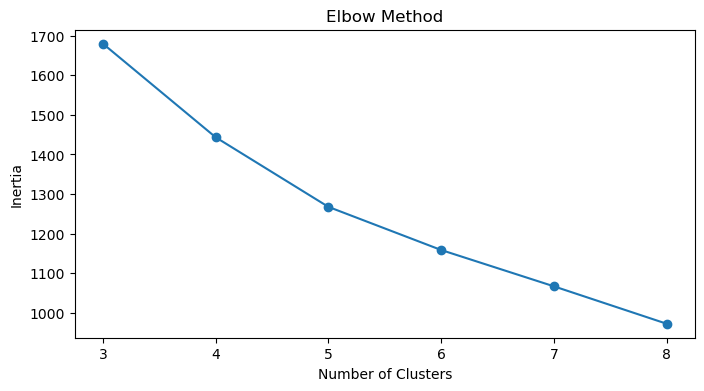

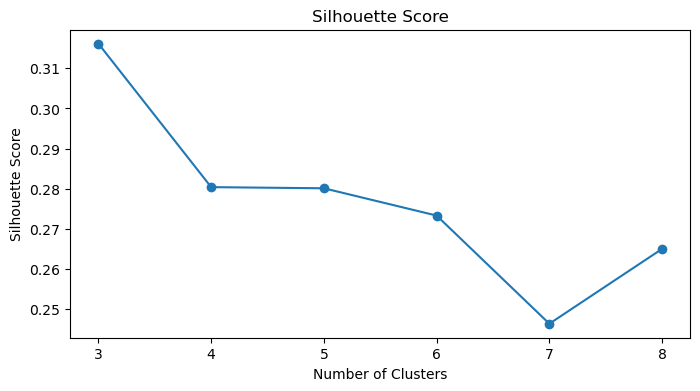

,k,inertia,silhouette
0,3,1679.513763,0.316115
1,4,1443.162618,0.280422
2,5,1267.439687,0.280137
3,6,1158.514361,0.273343
4,7,1066.787648,0.246429
5,8,972.312830,0.265059


In [72]:
#K-Means 수행 전 K 설정 위한 inertia, silhouette score 확인
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(3, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_valid_cluster)

    inertias.append(kmeans.inertia_)


    silhouette_scores.append(silhouette_score(X_valid_cluster, labels))


plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig('Elbow Method.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.savefig('Silhouette .png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [79]:
#k=3으로 설정 후 K-Means 진행

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_cluster)
anomaly_test_df["cluster"] = kmeans.predict(X_test_cluster)

anomaly_test_df["cluster"].value_counts().sort_index()

C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


cluster
1    69
2    90
Name: count, dtype: int64

In [80]:
#클러스터 별 feature 평균값 확인
cluster_profile = (
    anomaly_test_df
    .groupby("cluster")[cluster_feature_cols]
    .mean()
)

cluster_profile

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
1,3.425598,3.848841,4.785625,3.713379,0.276812,-0.016024,0.106663,-0.091235
2,0.065904,0.973459,-1.191754,5.100577,3.939417,-0.009030,0.027934,0.214671


In [81]:
#평균값 표준화 시킨 후 재확인
scaler2 = StandardScaler()
scaler2.fit(X_train_cluster)

cluster_profile_scaled = pd.DataFrame(
    scaler2.transform(cluster_profile),
    columns=cluster_feature_cols,
    index=cluster_profile.index
)

cluster_profile_scaled

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
1,0.367444,0.419185,1.797597,1.011357,-0.837904,-0.230518,-0.559740,-0.416167
2,-0.832806,-0.731667,-0.878712,1.629298,0.821661,-0.224986,-0.582836,-0.159773


In [82]:
#클러스터별 주요 특징
for cluster_id in sorted(anomaly_test_df["cluster"].unique()):
    print(f"\n===== Cluster {cluster_id} 주요 특징 =====")

    row = cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    print(row.head(5))


===== Cluster 1 주요 특징 =====
daily_return          1.797597
volatility_5d         1.011357
volume_ma20_ratio     0.419185
vol_chg_rate          0.367444
upper_shadow_ratio   -0.230518
Name: 1, dtype: float64

===== Cluster 2 주요 특징 =====
volatility_5d             1.629298
drawdown_after_peak_5d    0.821661
upper_shadow_streak_5d   -0.159773
upper_shadow_ratio       -0.224986
body_ratio               -0.582836
Name: 2, dtype: float64


In [83]:
anomaly_test_df.to_csv("anomaly_cluster_result.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv("cluster_profile_raw.csv", encoding="utf-8-sig")
cluster_profile_scaled.to_csv("cluster_profile_scaled.csv", encoding="utf-8-sig")